In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from cuml.decomposition import PCA
import cuml
import cudf
import matplotlib.pyplot as plt

# 读取压缩文件
file_path = '/mnt/workspace/IRISeq/hip_demo_connection_matrix.csv.gz'

# 使用 pandas 读取
connection_matrix = pd.read_csv(file_path, compression='gzip', index_col=0, header=0)


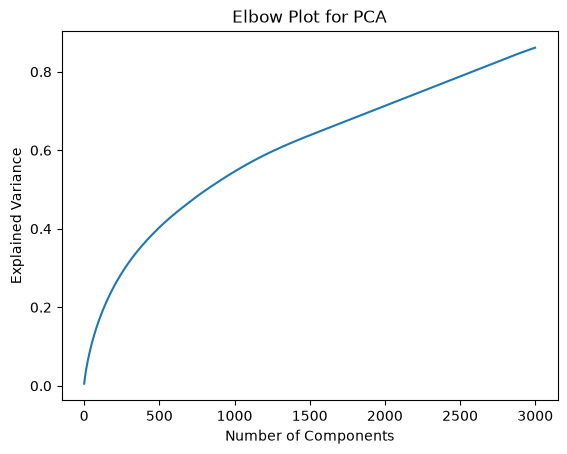

In [28]:
# Log1p transformation
connection_matrix_log1p = np.log1p(connection_matrix)

# Standardize the data (optional but often recommended)
scaler = StandardScaler()
connection_matrix_standardized = scaler.fit_transform(connection_matrix_log1p)

# Perform PCA on the standardized and log-transformed data
pca = PCA(n_components=3000)
pca.fit(connection_matrix_standardized)

# Plot the explained variance as a function of the number of components
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Elbow Plot for PCA')
plt.show()

In [2]:
# Log1p transformation
connection_matrix_log1p = np.log1p(connection_matrix)

# Standardize the data (optional but often recommended)
scaler = StandardScaler()
connection_matrix_standardized = scaler.fit_transform(connection_matrix_log1p)

# Perform PCA on the standardized and log-transformed data
pca = PCA(n_components=2500)
connection_matrix_pca = pca.fit_transform(connection_matrix_standardized)

In [19]:
# Set random seed for reproducibility
SEED = 42  # Set this to your desired seed value

# Create and fit the UMAP transformer
mapper = cuml.UMAP(
    n_neighbors=20,
    min_dist=0.75,
    metric='cosine',
    random_state=SEED,
    n_epochs=20000,
    learning_rate=1.0,
    verbose=True
)
coords = mapper.fit_transform(connection_matrix_pca)

[2026-07-11 22:20:44.404] [CUML] [debug] Building knn graph using build_algo='brute_force_knn'
[2026-07-11 22:20:44.732] [CUML] [debug] Computing KNN Graph
[2026-07-11 22:20:44.971] [CUML] [debug] Computing fuzzy simplicial set


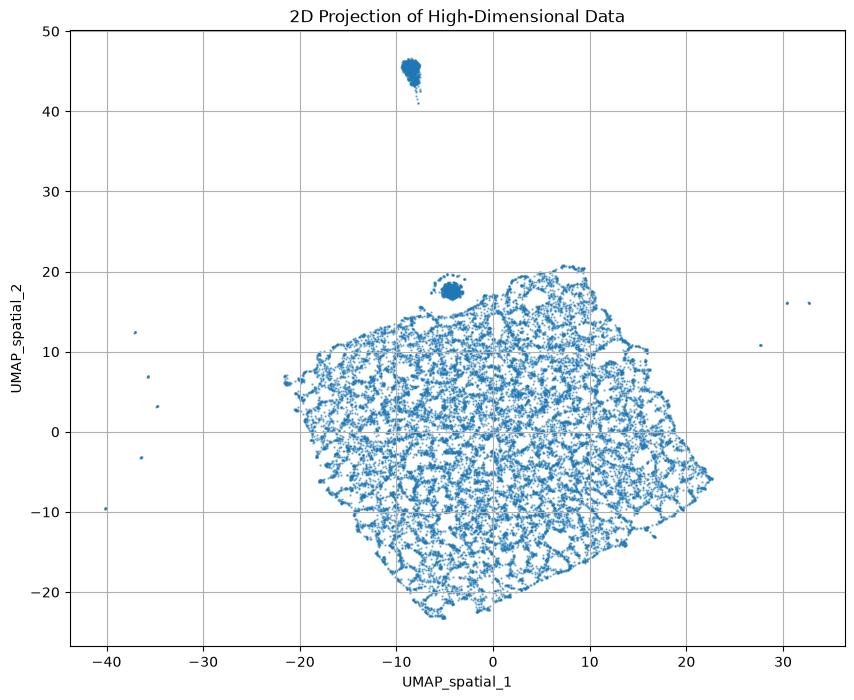

In [20]:
import matplotlib.pyplot as plt

x = coords[:, 0]  # First column corresponds to umap1
y = coords[:, 1]  # Second column corresponds to umap2

plt.figure(figsize=(10, 8))  # Set the figure size
plt.scatter(x, y, alpha=0.5, s=.5)  # Create a scatter plot
plt.title('2D Projection of High-Dimensional Data')
plt.xlabel('UMAP_spatial_1')
plt.ylabel('UMAP_spatial_2')
plt.grid(True)
plt.show()

In [21]:
output_file = '/mnt/workspace/IRISeq/umap_coords.csv'

# 将 cell name 作为第一列保存
umap_df = pd.DataFrame(coords, columns=['UMAP1', 'UMAP2'])
# 关键：添加 cell name 列（从 connection_matrix 的索引获取）
umap_df['cell_name'] = connection_matrix.index.tolist()  # 或者用 .reset_index()

# 调整列顺序，让 cell_name 在第一列
umap_df = umap_df[['cell_name', 'UMAP1', 'UMAP2']]

# 保存，index=False 但 cell_name 列已经包含在数据中
umap_df.to_csv(output_file, index=False)

In [37]:
import scanpy as sc

# 1. 读取数据
adata = sc.read_h5ad('/mnt/workspace/IRISeq/adata_full.h5ad')

# 查看基本信息
print(adata)

AnnData object with n_obs × n_vars = 16997 × 39984
    obs: 'total_UMI_count', 'not_aligned_UMI_count', 'not_aligned_ratio', 'Exon_count', 'Exon_ratio', 'UMI_count'
    var: 'Gene_type', 'Gene_name'
    layers: None


In [52]:
adata.obs.head()

,total_UMI_count,not_aligned_UMI_count,not_aligned_ratio,Exon_count,Exon_ratio,UMI_count
Cell_name,,,,,,
SRR29481264.ACACCGTA-AACAACCG-CTCACAGT-TCGTGCAA,126,3.0,0.023810,123,0.976190,123.0
SRR29481264.ACACCGTA-AACACGAC-ACACTCAG-AGTGCGAT,206,2.0,0.009709,198,0.961165,204.0
SRR29481264.ACACCGTA-AACACGAC-CAAGGTGA-TCACGGAT,10892,303.0,0.027819,10390,0.953911,10589.0
SRR29481264.ACACCGTA-AACACGAC-GGCTCAAT-ACGCTCTA,65,0.0,0.000000,62,0.953846,65.0
SRR29481264.ACACCGTA-AACCAGGT-AGCACATG-CCTAACGC,418,10.0,0.023923,400,0.956938,408.0


In [23]:
adata.var.head()

,Gene_type,Gene_name
Gene_id,,
ENSMUSG00000000001.5,protein_coding,Gnai3
ENSMUSG00000000003.16,protein_coding,Pbsn
ENSMUSG00000000028.16,protein_coding,Cdc45
ENSMUSG00000000031.20,lncRNA,H19
ENSMUSG00000000037.18,protein_coding,Scml2


In [38]:
# 提取细胞ID（去掉SRR前缀，保留后面部分）
adata.obs['cell_short'] = adata.obs_names.str.split('.').str[1]

# ==================== 3. 过滤基因 ====================

# 基因ID去掉版本号（例如：ENSMUSG00000000001.5 -> ENSMUSG00000000001）
adata.var['gene_id_no_version'] = adata.var_names.str.split('.').str[0]

# 替换基因名为Gene_name（更易读）
adata.var.index = adata.var['Gene_name'].astype(str)
adata.var_names_make_unique()

# ==================== 4. 质控过滤 ====================
# 过滤低质量细胞（至少300个UMI）
sc.pp.filter_cells(adata, min_counts=300)

# 计算线粒体基因比例（小鼠线粒体基因是 mt- 开头）
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 过滤高线粒体细胞（脑组织通常用5-10%，这里用10%）
adata = adata[adata.obs.pct_counts_mt < 10, :]

# 过滤低表达基因（至少在3个细胞中表达）
sc.pp.filter_genes(adata, min_cells=3)

# ==================== 5. 标准化 ====================
# 标准化到1万UMI
sc.pp.normalize_total(adata, target_sum=1e4)

# 对数化
sc.pp.log1p(adata)

# ==================== 6. 高变基因筛选 ====================
# 使用seurat_v3方法（需要安装scikit-misc）
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')

# 保存原始数据（包含所有基因），后续只使用高变基因
adata.raw = adata
adata = adata[:, adata.var.highly_variable]

# ==================== 7. 回归与缩放 ====================
# 回归掉测序深度和线粒体比例的影响
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# 缩放基因表达（均值为0，方差为1，截断到[-10,10]）
sc.pp.scale(adata, max_value=10)

# ==================== 8. PCA ====================
sc.tl.pca(adata, svd_solver='arpack')

/root/miniforge3/envs/UMAP_GPU/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:279: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
/tmp/ipykernel_1693/736632471.py:36: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')
/tmp/ipykernel_1693/736632471.py:44: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])


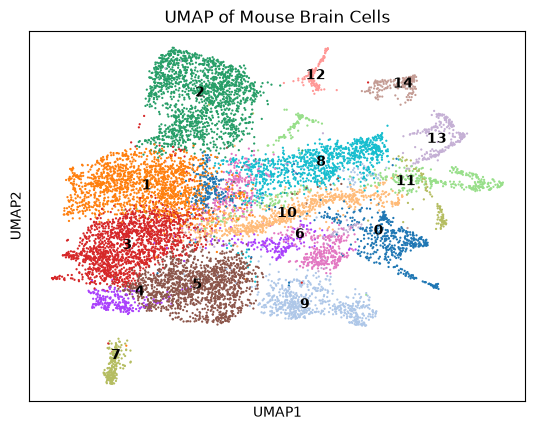

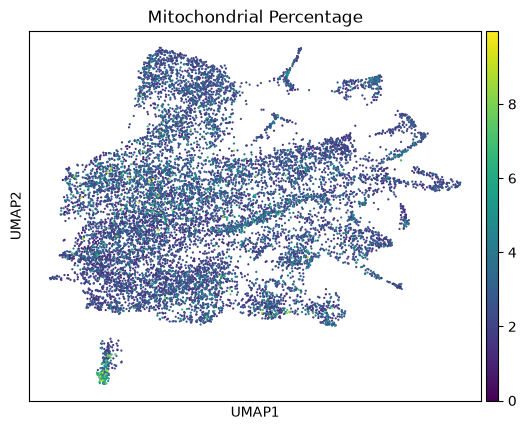

In [39]:
# ==================== 9. 邻居图 ====================
# 脑组织细胞异质性高，可以用更多的PC（15-20）
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)

# ==================== 10. UMAP降维 ====================
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

# ==================== 11. 聚类 ====================
# 脑组织细胞类型多，用较高分辨率（0.8-1.2）
sc.tl.leiden(adata, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)

# ==================== 12. 可视化检查 ====================
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', title='UMAP of Mouse Brain Cells')

# 检查线粒体基因在UMAP上的分布
sc.pl.umap(adata, color=['pct_counts_mt'], title='Mitochondrial Percentage')

In [25]:
print(adata)

AnnData object with n_obs × n_vars = 11555 × 2000
    obs: 'total_UMI_count', 'not_aligned_UMI_count', 'not_aligned_ratio', 'Exon_count', 'Exon_ratio', 'UMI_count', 'cell_short', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'Gene_type', 'Gene_name', 'gene_id_no_version', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None


In [28]:
adata.obs.head()

,total_UMI_count,not_aligned_UMI_count,not_aligned_ratio,Exon_count,Exon_ratio,UMI_count,cell_short,n_counts,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden
Cell_name,,,,,,,,,,,,,
SRR29481264.ACACCGTA-AACACGAC-CAAGGTGA-TCACGGAT,10892,303.0,0.027819,10390,0.953911,10589.0,ACACCGTA-AACACGAC-CAAGGTGA-TCACGGAT,10589,4551,10589,212,2.002078,0
SRR29481264.ACACCGTA-AACCAGGT-AGCACATG-CCTAACGC,418,10.0,0.023923,400,0.956938,408.0,ACACCGTA-AACCAGGT-AGCACATG-CCTAACGC,408,335,408,16,3.921569,1
SRR29481264.ACACCGTA-AACCAGGT-AGTGGTAC-AGTACCGT,1358,39.0,0.028719,1294,0.952872,1319.0,ACACCGTA-AACCAGGT-AGTGGTAC-AGTACCGT,1319,973,1319,19,1.440485,4
SRR29481264.ACACCGTA-AACCAGGT-CTATGGAG-GTCCGTTA,946,25.0,0.026427,889,0.939746,921.0,ACACCGTA-AACCAGGT-CTATGGAG-GTCCGTTA,921,733,921,14,1.520087,6
SRR29481264.ACACCGTA-AACCAGGT-CTGGTTCA-CCTAAGTC,689,23.0,0.033382,654,0.949202,666.0,ACACCGTA-AACCAGGT-CTGGTTCA-CCTAAGTC,666,540,666,16,2.402402,7


In [29]:
adata.var.head()

,Gene_type,Gene_name,gene_id_no_version,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mean,std
Gene_name,,,,,,,,,,,,,,,,
Tbx4,protein_coding,Tbx4,ENSMUSG00000000094,False,5,0.000432,99.956841,5,5,True,774.0,0.000591,0.001251,1.369299,-4.971691e-12,0.035363
Fgf23,protein_coding,Fgf23,ENSMUSG00000000182,False,5,0.000432,99.956841,5,5,True,788.0,0.000570,0.001169,1.367506,-1.257518e-11,0.034188
Itga5,protein_coding,Itga5,ENSMUSG00000000555,False,34,0.003366,99.706517,39,34,True,1964.0,0.004004,0.007601,1.239290,3.324713e-13,0.087183
Tat,protein_coding,Tat,ENSMUSG00000001670,False,7,0.000604,99.939577,7,7,True,73.0,0.001159,0.002952,1.677199,-8.199699e-12,0.054327
Folr1,protein_coding,Folr1,ENSMUSG00000001827,False,180,0.027277,98.446267,316,180,True,1976.0,0.025011,0.047231,1.238617,1.445494e-11,0.217205


In [40]:
# 读取空间坐标
spatial_df = pd.read_csv('/mnt/workspace/IRISeq/umap_coords.csv')

# 匹配空间坐标到adata
spatial_df = spatial_df.set_index('cell_name')
adata.obs[['spatial_x', 'spatial_y']] = spatial_df[['UMAP1', 'UMAP2']].reindex(
    adata.obs['cell_short']
).values

# 删除临时列
del adata.obs['cell_short']

# 检查匹配情况
print(f"缺失空间坐标的细胞数: {adata.obs['spatial_x'].isna().sum()}")

缺失空间坐标的细胞数: 272


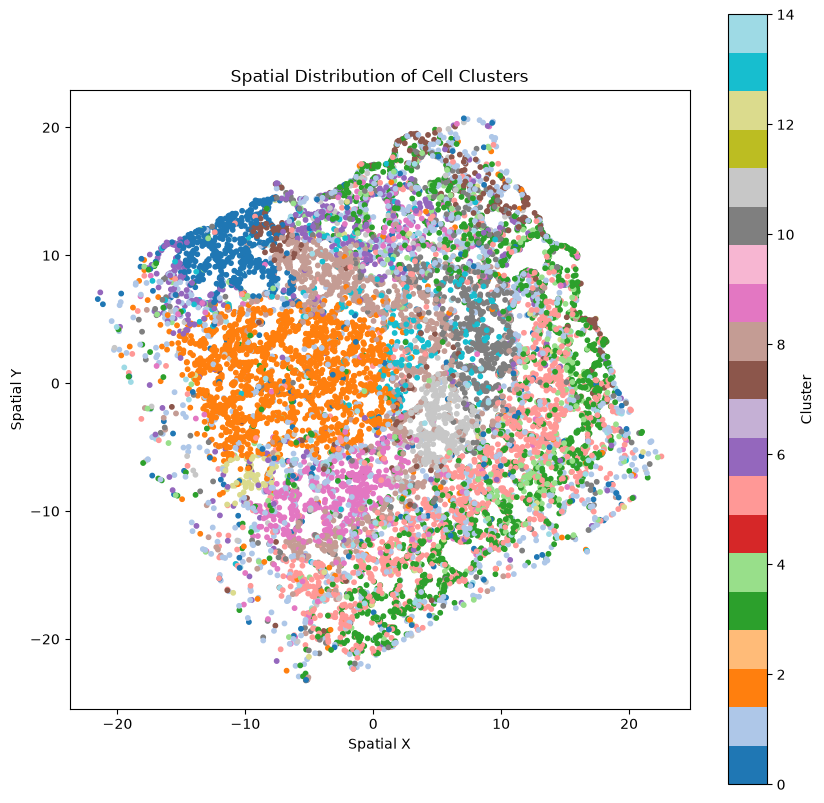

In [41]:
plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    adata.obs['spatial_x'], 
    adata.obs['spatial_y'],
    c=adata.obs['leiden'].astype('category').cat.codes,  # 聚类标签转为数值
    s=10,
    cmap='tab20',
    alpha=1
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Spatial X')
plt.ylabel('Spatial Y')
plt.title('Spatial Distribution of Cell Clusters')
plt.gca().set_aspect('equal')  # 保持纵横比
plt.show()